# Blood Pressure Logistic Regression

## Load modules

In [1]:
# ============================================
# 1. 라이브러리 불러오기
# ============================================

import numpy as np                 # 수치 계산을 위한 라이브러리
import tensorflow as tf           # 딥러닝 모델을 만들기 위한 라이브러리
import matplotlib.pyplot as plt   # 그래프를 그리기 위한 라이브러리

# 현재 설치된 라이브러리 버전 확인 (환경 체크용)
print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.16.2
Matplotlib Version :3.10.0


## Input and Label

In [3]:
# ============================================
# 2. 데이터 준비
# ============================================

# 입력 데이터 (나이, BMI)
# 예: [25, 22] → 나이 25세, BMI 22
x_input = tf.constant([
    [25,22],[25,26],[25,30],
    [35,22],[35,26],[35,30],
    [45,22],[45,26],[45,30],
    [55,22],[55,26],[55,30],
    [65,22],[65,26],[65,30],
    [73,22],[73,26],[73,30]
], dtype=tf.float32)

# 정답(label)
# 0 = 정상, 1 = 고혈압 (이진 분류)
labels = tf.constant([
    [0],[0],[1],
    [0],[1],[1],
    [0],[1],[1],
    [1],[1],[1],
    [1],[1],[1],
    [1],[1],[1]
], dtype=tf.float32)

## Min Max Scaler

In [4]:
# ============================================
# 3. 데이터 정규화 (매우 중요)
# ============================================

# 원본 데이터 따로 저장 (나중에 출력용)
x_input_org = x_input

# 각 컬럼의 최소값, 최대값 구하기
x_min = np.min(x_input, axis=0)
x_max = np.max(x_input, axis=0)

# 정규화 (0~1 사이로 변환)
# 이유: 학습이 더 잘 되도록 하기 위해
x_input = (x_input - x_min) / (x_max - x_min)

In [18]:
x_input

<tf.Tensor: shape=(18, 2), dtype=float32, numpy=
array([[0.        , 0.        ],
       [0.        , 0.5       ],
       [0.        , 1.        ],
       [0.20833333, 0.        ],
       [0.20833333, 0.5       ],
       [0.20833333, 1.        ],
       [0.41666666, 0.        ],
       [0.41666666, 0.5       ],
       [0.41666666, 1.        ],
       [0.625     , 0.        ],
       [0.625     , 0.5       ],
       [0.625     , 1.        ],
       [0.8333333 , 0.        ],
       [0.8333333 , 0.5       ],
       [0.8333333 , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.5       ],
       [1.        , 1.        ]], dtype=float32)>

## Model 정의

In [5]:
# ============================================
# 4. 모델 만들기
# ============================================

model = tf.keras.models.Sequential([
    
    # 입력층 (입력 데이터가 2개 → 나이, BMI)
    tf.keras.Input(shape=(2,)),
    
    # Dense Layer (출력 1개 → 확률)
    # sigmoid → 0~1 사이 값 (확률)
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [6]:
# ============================================
# 5. 모델 학습 설정
# ============================================

model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),  # 경사하강법
    loss='binary_crossentropy',  # 이진 분류용 손실 함수
    metrics=['accuracy']         # 정확도 출력
)

## 학습 (Training)

In [10]:

# ============================================
# 6. 모델 학습
# ============================================



history = model.fit(
    x_input,     # 입력 데이터
    labels,      # 정답
    epochs=500  # 반복 학습 횟수
)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8889 - loss: 0.2083
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8889 - loss: 0.2082
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8889 - loss: 0.2081
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8889 - loss: 0.2080
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8889 - loss: 0.2079
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8889 - loss: 0.2079
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8889 - loss: 0.2078
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8889 - loss: 0.2077
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8889 - loss: 0.2076
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8889 - loss: 0.2075
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8889 - loss: 0.2074
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8889 - lo

### Plot

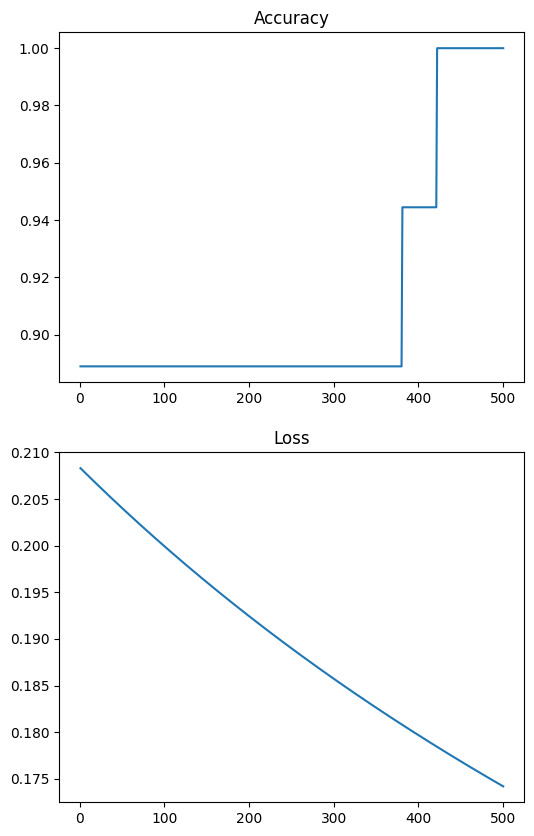

In [11]:
# ============================================
# 7. 학습 결과 그래프 출력
# ============================================

loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))

# 정확도 그래프
plt.subplot(2, 1, 1)
plt.title('Accuracy')
plt.plot(epochs, history.history['accuracy'])

# 손실(loss) 그래프
plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, loss)

plt.show()

## Training 결과 Test

In [12]:
# ============================================
# 8. 학습 결과 확인
# ============================================

# 예측값 계산
H_x = model.predict(x_input)

# 원본 데이터 기준으로 결과 출력
for x, h, l in zip(x_input_org, H_x, labels):
    
    print("Age:{}, BMI:{:>7.4} => Result:{:>7.4} [label => {}]"
          .format(x[0], x[1], h[0], l))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Age:25.0, BMI:   22.0 => Result: 0.1238 [label => [0.]]
Age:25.0, BMI:   26.0 => Result: 0.4927 [label => [0.]]
Age:25.0, BMI:   30.0 => Result: 0.8697 [label => [1.]]
Age:35.0, BMI:   22.0 => Result: 0.2696 [label => [0.]]
Age:35.0, BMI:   26.0 => Result: 0.7173 [label => [1.]]
Age:35.0, BMI:   30.0 => Result: 0.9458 [label => [1.]]
Age:45.0, BMI:   22.0 => Result: 0.4909 [label => [0.]]
Age:45.0, BMI:   26.0 => Result: 0.8689 [label => [1.]]
Age:45.0, BMI:   30.0 => Result: 0.9785 [label => [1.]]
Age:55.0, BMI:   22.0 => Result: 0.7159 [label => [1.]]
Age:55.0, BMI:   26.0 => Result: 0.9454 [label => [1.]]
Age:55.0, BMI:   30.0 => Result: 0.9917 [label => [1.]]
Age:65.0, BMI:   22.0 => Result: 0.8681 [label => [1.]]
Age:65.0, BMI:   26.0 => Result: 0.9784 [label => [1.]]
Age:65.0, BMI:   30.0 => Result: 0.9968 [label => [1.]]
Age:73.0, BMI:   22.0 => Result: 0.9342 [label => [1.]]
Age:73.0, BMI:   26.0 => Result: 0.9899 [label => [1.]]
Age:73.0, 

#  로지스틱 회귀 결과 해석
## 1. 결과의 의미
출력된 `Result` 값은 **고혈압일 확률(0 ~ 1)** 입니다.
- 0에 가까움 → 정상 (0)
- 1에 가까움 → 고혈압 (1)

일반적인 판단 기준은 다음과 같습니다.
0.5 미만 → 정상  
0.5 이상 → 고혈압  

## 2. 전체 흐름 해석
### 나이에 따른 변화
- 20대 → 대부분 낮은 확률 (0.1 ~ 0.8)
- 40대 → 중간 확률 (0.4 ~ 0.9)
- 60대 이상 → 거의 1에 가까움

즉,  
**나이가 증가할수록 고혈압 확률이 증가하는 패턴을 학습함**

### BMI에 따른 변화
같은 나이에서도 BMI가 증가하면 확률이 상승함

예시
Age 25 기준  
BMI 22 → 0.1238  
BMI 30 → 0.8697  

즉,  
**BMI가 높을수록 고혈압 확률이 증가함**

## 3. 경계 영역 (중요)
다음 값들은 모델이 판단을 확신하지 못하는 구간입니다.
Age:25, BMI:26 → 0.4927  
Age:45, BMI:22 → 0.4909  

특징
- 0.5 근처 값
- 정상과 고혈압 사이 경계
- 실제로도 판단이 어려운 케이스

## 4. 실제값과 비교

대부분의 경우
- 실제값 0 → 낮은 확률
- 실제값 1 → 높은 확률

즉,  
**모델이 전반적인 패턴을 정확하게 학습함**


## 5. 모델의 동작 방식
이 모델은 내부적으로 다음과 같은 계산을 수행함
z = (나이 × 가중치) + (BMI × 가중치) + bias  

그리고 확률 = sigmoid(z)
즉,  
**나이와 BMI를 하나의 직선 기준으로 나누는 구조**

## 6. 핵심 해석

이 결과는 다음을 의미함
- 나이와 BMI가 증가할수록 고혈압 확률이 증가함
- 모델은 이 관계를 잘 학습함
- 경계 영역에서는 예측이 애매함

## 7. 한 줄 정리
이 모델은  
**나이와 BMI를 기반으로 고혈압 여부를 확률로 판단하는 정상적인 로지스틱 회귀 모델임**

## Predict

In [13]:
# ============================================
# 9. 새로운 데이터 예측 함수
# ============================================

def predict(x):
    
    # 입력 데이터도 반드시 정규화 해야 함
    x_norm = (x - x_min) / (x_max - x_min)
    
    return model.predict(x_norm)

In [17]:
# ============================================
# 10. 테스트 데이터 예측
# ============================================

x_test = tf.constant([[50.0, 25.0]], dtype=tf.float32)

H_x = predict(x_test)

print("Age : {}, BMI : {} => Result : {:>7.4}"
      .format(x_test[0,0], x_test[0,1], H_x[0,0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Age : 50.0, BMI : 25.0 => Result :  0.8687
